In [1]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')
from python.polygon_based_correction import *
from python.animation import *
from eval.eval import *
from python.dataset_conversion import *
from python.misprediction_classifier import *
from autoencoder.src.data_loader import *

sleap.versions()
sleap.system_summary()

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit, ParameterGrid, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, make_scorer, recall_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


# Load data

In [2]:
predicted_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_with_scores.slp'
predicted_dataset = sleap.load_file(predicted_dataset_path)
print(predicted_dataset)

corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)

pred_pts_with_scores = get_all_untracked_points(predicted_dataset, 
                                                interpolate=False, use_labeled_only=False, load_pred_score=True)
gt_pts = get_all_untracked_points(corrected_dataset, interpolate=False, use_labeled_only=True)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 3)


3000it [00:03, 800.29it/s]


Missing point count: 0
reorder_idx.shape: (17,)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 783.75it/s]

Missing point count: 0
reorder_idx.shape: (17,)


In [3]:
vid_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/animal_1_1h_20s.mp4'
vid = video_loader(vid_path)
print(vid.shape, vid.min(), vid.max())

(3000, 170, 174) 0.00784313725490196 1.0


In [4]:
missing_count = get_missing_count(pred_pts_with_scores)
print(f'total missing count in predicted points: {missing_count.sum()}')

missing_count = get_missing_count(gt_pts)
print(f'total missing count in ground truth points: {missing_count.sum()}')


total missing count in predicted points: 945.0
total missing count in ground truth points: 0.0


# Label assignment

In [21]:
pred_labels = get_labels(pred_pts_with_scores, gt_pts, dist_thres=5)

total point count = 51000, correct = 49577, incorrect = 1423


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/labels_check_20s.mp4
Animation saved to /home/mingxiao/Desktop/animation/labels_check_20s.mp4


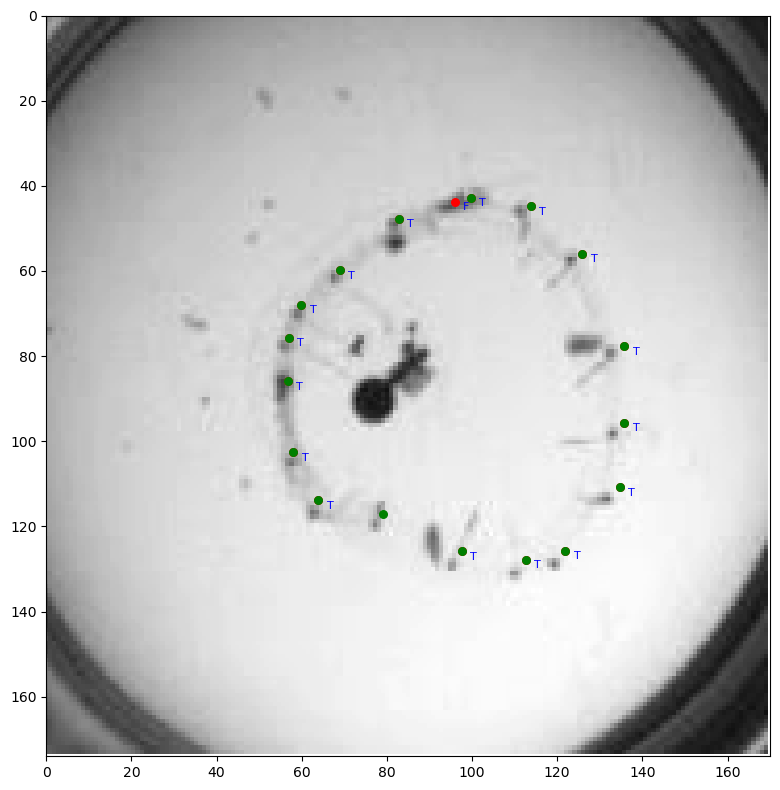

In [43]:
labels_check_20s_path = '/home/mingxiao/Desktop/animation/labels_check_20s.mp4'
text_dict = {0: 'F', 1: 'T'}
animate_classification_results(pred_pts_with_scores, gt_pts, pred_labels, 
                               bg_video=vid, bg_video_start_idx=0, 
                               text_dict=text_dict, output_path=labels_check_20s_path);

# Data augmentation

In [10]:
def augment_pred_pts(pred_pts, augment_rate=0.5):
    pred_pts_augmented = pred_pts[1:, :, :2].copy()
    missing_cnt = get_missing_count(pred_pts_augmented)
    augment_rate = 0.5
    selected_frames = np.random.choice(pred_pts_augmented.shape[0], int(pred_pts_augmented.shape[0] * augment_rate), replace=False)

    for frame_idx in selected_frames:
        curr_pts = pred_pts_augmented[frame_idx]
        aug_candidates = np.where(missing_cnt[frame_idx] == 0)[0]
        aug_pt_indices = np.random.choice(aug_candidates, np.random.randint(1, 5), replace=False)
        for pt_idx in aug_pt_indices:
            pred_pts_augmented[frame_idx, pt_idx] += np.random.normal(20, 10, size=2)
    
    return pred_pts_augmented

pred_pts_augmented = augment_pred_pts(pred_pts_with_scores, augment_rate=0.9)
aug_labels = get_labels(pred_pts_augmented, gt_pts[1:], dist_thres=5)

total point count = 50983, correct = 45890, incorrect = 5093


# Get training dataset

In [7]:
X_train, X_test, y_train, y_test, X, y, scaler = load_20s_dataset(dist_thres=5)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 3)


3000it [00:03, 978.67it/s] 


Missing point count: 0
reorder_idx.shape: (17,)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 959.65it/s] 


Missing point count: 0
reorder_idx.shape: (17,)
total point count = 50983, correct = 49560, incorrect = 1423
(50038, 4) (50038,)


# Train classifiers

## SVM

### default 

In [8]:
svm_clf = SVC(kernel='rbf')  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.990607513988809
              precision    recall  f1-score   support

         0.0       0.56      0.10      0.18        48
         1.0       0.99      1.00      1.00      4956

    accuracy                           0.99      5004
   macro avg       0.77      0.55      0.59      5004
weighted avg       0.99      0.99      0.99      5004



### imbalanced class weights

In [10]:
class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9852118305355716
              precision    recall  f1-score   support

         0.0       0.32      0.50      0.39        48
         1.0       1.00      0.99      0.99      4956

    accuracy                           0.99      5004
   macro avg       0.66      0.74      0.69      5004
weighted avg       0.99      0.99      0.99      5004



In [9]:
class_weights = {0: 10, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9842126298960832
              precision    recall  f1-score   support

         0.0       0.32      0.56      0.41        48
         1.0       1.00      0.99      0.99      4956

    accuracy                           0.98      5004
   macro avg       0.66      0.78      0.70      5004
weighted avg       0.99      0.98      0.99      5004



In [11]:
class_weights = {0: 100, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8924860111910472
              precision    recall  f1-score   support

         0.0       0.07      0.88      0.14        48
         1.0       1.00      0.89      0.94      4956

    accuracy                           0.89      5004
   macro avg       0.54      0.88      0.54      5004
weighted avg       0.99      0.89      0.93      5004



### resampling

In [1]:
def custom_resample(X, y, minority_class=0, minor_to_major_ratio=0.5, dowmsample_majority_ratio=1):
    """
    Resample dataset by undersampling majority class and oversampling minority class
    
    Args:
        X: features array
        y: labels array
        minority_class: the class to oversample (default 0)
        minor_to_major_ratio: desired ratio of minority to majority samples (default 0.5)
        dowmsample_majority_ratio: ratio of majority to minority samples to downsample (default 1; no downsampling)
    """
    # Separate majority and minority classes
    X_majority = X[y != minority_class]
    y_majority = y[y != minority_class]
    X_minority = X[y == minority_class]
    y_minority = y[y == minority_class]
    
    # Calculate desired number of samples
    n_minority = len(X_minority)
    n_majority = len(X_majority)
    desired_minority = int(n_majority * minor_to_major_ratio * dowmsample_majority_ratio)
    
    # Downsample majority class
    if dowmsample_majority_ratio < 1:
        indices = np.random.choice(len(X_majority), int(n_majority * dowmsample_majority_ratio), replace=False)
        X_majority_resampled = X_majority[indices]
        y_majority_resampled = y_majority[indices]
    else:
        X_majority_resampled = X_majority
        y_majority_resampled = y_majority
    
    # Oversample minority class
    if desired_minority > n_minority:
        indices = np.random.choice(len(X_minority), desired_minority, replace=True)
        X_minority_resampled = X_minority[indices]
        y_minority_resampled = y_minority[indices]
    else:
        X_minority_resampled = X_minority
        y_minority_resampled = y_minority
    
    print(f'majority count: {len(X_majority_resampled)}, minority count: {len(X_minority_resampled)}')
    
    # Combine the datasets
    X_resampled = np.vstack([X_majority_resampled, X_minority_resampled])
    y_resampled = np.hstack([y_majority_resampled, y_minority_resampled])
    
    # Shuffle
    indices = np.arange(len(X_resampled))
    np.random.shuffle(indices)
    
    return X_resampled[indices], y_resampled[indices]

In [ ]:
# TODO: add data augmentation (rotation/noise/use interpolation to make false positives)

#### upsample minority only

In [13]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.5)  # Aim for minority class to be half size of majority

class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 44604, minority count: 22302
Accuracy: 0.7835731414868106
              precision    recall  f1-score   support

         0.0       0.04      0.96      0.08        48
         1.0       1.00      0.78      0.88      4956

    accuracy                           0.78      5004
   macro avg       0.52      0.87      0.48      5004
weighted avg       0.99      0.78      0.87      5004



In [14]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.2)  # Aim for minority class to be half size of majority

class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 44604, minority count: 8920
Accuracy: 0.8701039168665068
              precision    recall  f1-score   support

         0.0       0.06      0.88      0.11        48
         1.0       1.00      0.87      0.93      4956

    accuracy                           0.87      5004
   macro avg       0.53      0.87      0.52      5004
weighted avg       0.99      0.87      0.92      5004



#### upsample minority & dowmsample majority

In [16]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.2,  # Aim for minority class to be half size of majority
    dowmsample_majority_ratio=0.8)

class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 35683, minority count: 7136
Accuracy: 0.8723021582733813
              precision    recall  f1-score   support

         0.0       0.06      0.88      0.12        48
         1.0       1.00      0.87      0.93      4956

    accuracy                           0.87      5004
   macro avg       0.53      0.87      0.52      5004
weighted avg       0.99      0.87      0.92      5004



In [17]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.2,  # Aim for minority class to be half size of majority
    dowmsample_majority_ratio=0.6)

class_weights = {0: 5, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 26762, minority count: 5352
Accuracy: 0.8647082334132694
              precision    recall  f1-score   support

         0.0       0.06      0.90      0.11        48
         1.0       1.00      0.86      0.93      4956

    accuracy                           0.86      5004
   macro avg       0.53      0.88      0.52      5004
weighted avg       0.99      0.86      0.92      5004



In [19]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, minority_class=0,
    minor_to_major_ratio=0.2,  # Aim for minority class to be half size of majority
    dowmsample_majority_ratio=0.6)

class_weights = {0: 8, 1: 1} 
svm_clf = SVC(kernel='rbf', class_weight=class_weights)  # RBF kernel for non-linearity
svm_clf.fit(X_train_resampled, y_train_resampled)

y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

majority count: 26762, minority count: 5352
Accuracy: 0.8309352517985612
              precision    recall  f1-score   support

         0.0       0.05      0.94      0.10        48
         1.0       1.00      0.83      0.91      4956

    accuracy                           0.83      5004
   macro avg       0.52      0.88      0.50      5004
weighted avg       0.99      0.83      0.90      5004



### grid search + optimize for recall of class 0 + resampling

In [9]:
def grid_search_with_resampling(X, y, model, param_grid, 
                                n_splits=5, 
                                minority_class=0, 
                                minor_to_major_ratio=0.5,
                                dowmsample_majority_ratio=1):
    """
    Perform grid search with resampling in each fold
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    best_score = 0
    best_params = None
    best_model = None
    
    # Create scorer that focuses on minority class recall
    scorer = make_scorer(recall_score, pos_label=minority_class)
    
    # For each parameter combination
    for params in ParameterGrid(param_grid):
        fold_scores = []
        
        # For each fold
        for train_idx, val_idx in cv.split(X, y):
            # Split data
            X_train_fold = X[train_idx]
            y_train_fold = y[train_idx]
            X_val_fold = X[val_idx]
            y_val_fold = y[val_idx]
            
            # Resample training data
            X_train_resampled, y_train_resampled = custom_resample(
                X_train_fold, y_train_fold,
                minority_class=minority_class, 
                minor_to_major_ratio=minor_to_major_ratio,
                dowmsample_majority_ratio=dowmsample_majority_ratio
            )
            
            # Train model with current parameters
            model_fold = clone(model)
            model_fold.set_params(**params)
            model_fold.fit(X_train_resampled, y_train_resampled)
            
            # Score on validation set
            score = scorer(model_fold, X_val_fold, y_val_fold)
            fold_scores.append(score)
        
        # Average score across folds
        mean_score = np.mean(fold_scores)
        
        # Update best if improved
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            best_model = model_fold
            
        print(f"Params: {params}")
        print(f"Mean score: {mean_score:.3f}")
    
    return best_params, best_score, best_model

In [3]:
X_train_resampled, y_train_resampled = custom_resample(
    X_train, y_train, 
    minority_class=0, minor_to_major_ratio=0.5, dowmsample_majority_ratio=0.8)

majority count: 44620, minority count: 22310


### using best params from grid search

In [7]:
_, _, _, _, X_o, y_o, scaler_o = load_20s_dataset(load_2nn_dist=True, augment_rate=None, dist_thres=5)
_, _, _, _, X, y, _ = load_20s_dataset(load_2nn_dist=True, dist_thres=5, augment_rate=0.9, 
                                            scaler=scaler_o, augment_pt_range=(1, 5), noise_mean=20, noise_std=10)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 3)


3000it [00:03, 993.03it/s] 


Missing point count: 0
reorder_idx.shape: (17,)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 944.14it/s]


Missing point count: 0
reorder_idx.shape: (17,)
total point count = 50983, correct = 49560, incorrect = 1423
(50038, 4) (50038,)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 3)


3000it [00:03, 977.75it/s]


Missing point count: 0
reorder_idx.shape: (17,)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 970.56it/s]


Missing point count: 0
reorder_idx.shape: (17,)
total point count = 50983, correct = 43030, incorrect = 7953
(50038, 4) (50038,)


In [9]:
X_resampled, y_resampled = custom_resample(
    X, y, 
    minority_class=0, minor_to_major_ratio=0.2, dowmsample_majority_ratio=0.8)

params = {'C':0.1,'class_weight': {0:5,1:1},'gamma': 100.0}
svm_clf = SVC(**params)
svm_clf.fit(X_resampled, y_resampled)

SVC(C=0.1, class_weight={0: 5, 1: 1}, gamma=100.0)

In [10]:
y_o_pred = svm_clf.predict(X_o)
print(classification_report(y_o, y_o_pred))

              precision    recall  f1-score   support

         0.0       0.05      0.94      0.10       478
         1.0       1.00      0.84      0.92     49560

    accuracy                           0.85     50038
   macro avg       0.53      0.89      0.51     50038
weighted avg       0.99      0.85      0.91     50038



In [14]:
def get_checked_labels(y, y_pred, x_pred):
    if x_pred.ndim == 3:
        x_pred = x_pred[:, :, :2]
    checked_labels = (y * 2 + (y == y_pred)).astype(int)
    missing_mask = get_missing_count(x_pred).astype(int)
    print(f'missing count: {missing_mask.sum()}')
    frame_cnt, pt_cnt = x_pred.shape[:2]
    checked_labels_unraveled = np.full((frame_cnt,  pt_cnt), -1, dtype=int)
    label_idx = 0
    for frame_idx in range(frame_cnt):
        for pt_idx in range(pt_cnt):
            if not missing_mask[frame_idx, pt_idx]:
                checked_labels_unraveled[frame_idx, pt_idx] = checked_labels[label_idx]
                label_idx += 1
            
    return checked_labels_unraveled
checked_labels = get_checked_labels(y, y_o_pred, pred_pts_with_scores[1:])

missing count: 945


In [19]:
def unravel_labels(y, x_pred):
    if x_pred.ndim == 3:
        x_pred = x_pred[:, :, :2]
    missing_mask = get_missing_count(x_pred).astype(int)
    print(missing_mask.sum())
    frame_cnt, pt_cnt = x_pred.shape[:2]
    checked_labels_unraveled = np.full((frame_cnt,  pt_cnt), -1, dtype=int)
    label_idx = 0
    for frame_idx in range(frame_cnt):
        for pt_idx in range(pt_cnt):
            if not missing_mask[frame_idx, pt_idx]:
                checked_labels_unraveled[frame_idx, pt_idx] = y[label_idx]
                label_idx += 1
            
    return checked_labels_unraveled
unraveled_labels = unravel_labels(y, pred_pts_with_scores[1:])
unraveled_pred_labels = unravel_labels(y_o_pred, pred_pts_with_scores[1:])

945
945


In [16]:
def animate_classification_results(
        pred_pts: np.ndarray,  
        checked_labels: np.ndarray,
        x: int = 170,
        y: int = 174,
        fps: int = 50,
        bg_video: Union[sleap.Video, np.array] = None,
        bg_video_start_idx: int = 1,
        output_path: str = None,
        text_dict: dict = None
    ) -> animation.FuncAnimation:
    if text_dict is None:
        text_dict = {0: 'FP', 1: 'TN', 2: 'FN', 3: 'TP', -1: 'nan'}
    if pred_pts.shape[2] == 3:
        pred_pts = pred_pts[:, :, :2]
    
    # if checked_labels.shape[0] == pred_pts.shape[0]:
    #     checked_labels = checked_labels[bg_video_start_idx:]
    checked_labels = checked_labels[bg_video_start_idx:]
    pred_pts = pred_pts[bg_video_start_idx:]
    
    frame_cnt = pred_pts.shape[0]
    n_plots = 1
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, n_plots, figsize=(8*n_plots, 8))
    if n_plots == 1:
        axes = [axes]  # Make axes iterable when only one subplot
    
    # Initialize plot elements for each subplot
    lines = []
    scats = []
    bg_imgs = []
    texts = []  # Add list to store text annotations
    
    vid_max_val = 255 if isinstance(bg_video, sleap.Video) else 1
    
    for ax in axes:
        ax.set_xlim(0, x)
        ax.set_ylim(0, y)
        ax.invert_yaxis()
        
        # Initialize empty line and scatter objects for each subplot
        line, = ax.plot([], [], 'b-', lw=1)
        # pred_scat = ax.scatter([], [], c='yellow', s=30)
        # gt_scat = ax.scatter([], [], c='green', s=30)
        tp_scat = ax.scatter([], [], c='green', s=30)
        fp_scat = ax.scatter([], [], c='lightgreen', s=30)
        fn_scat = ax.scatter([], [], c='lightsalmon', s=30)
        tn_scat = ax.scatter([], [], c='red', s=30)
        bg_img = ax.imshow(np.zeros((y, x)), cmap='gray', vmin=0, vmax=vid_max_val)
        
        # Initialize empty text annotations
        frame_texts = []
        for _ in range(pred_pts.shape[1]):  # number of points per frame
            txt = ax.text(0, 0, '', fontsize=8, color='blue')
            frame_texts.append(txt)
        
        lines.append(line)
        scats.append([fp_scat, tn_scat, fn_scat, tp_scat]) # {0: 'FP', 1: 'TN', 2: 'FN', 3: 'TP', -1: 'nan'}
        bg_imgs.append(bg_img)
        texts.append(frame_texts)

    def init():
        plot_elements = []
        for line, (fp_scat, tn_scat, fn_scat, tp_scat), bg_img, frame_texts in zip(lines, scats, bg_imgs, texts):
            line.set_data([], [])
            fp_scat.set_offsets(np.zeros((0, 2)))
            tn_scat.set_offsets(np.zeros((0, 2)))
            fn_scat.set_offsets(np.zeros((0, 2)))
            tp_scat.set_offsets(np.zeros((0, 2)))
            for txt in frame_texts:
                txt.set_position((0, 0))
                txt.set_text('')
            plot_elements.extend([fp_scat, tn_scat, fn_scat, tp_scat, bg_img] + frame_texts)
        return plot_elements

    def animate(frame):
        plot_elements = []
        
        # Update background
        if bg_video is not None:
            if isinstance(bg_video, sleap.Video):
                bg_frame = bg_video.get_frame(frame + bg_video_start_idx)[:, :, 0]
            else:
                bg_frame = bg_video[frame + bg_video_start_idx]
            for bg_img in bg_imgs:
                bg_img.set_array(bg_frame)
        
        # Update each subplot
        for i, (pred_pt, checked_label, line, scat_lst, frame_texts) in enumerate(
            zip([pred_pts], [checked_labels], lines, scats, texts)):
            
            pred_points = pred_pt[frame]
            # pred_points_closed = np.vstack([pred_points, pred_points[0]])
            # gt_points_closed = np.vstack([gt_points, gt_points[0]])
            label_check = checked_label[frame]  # Get labels for current frame
            # Update scatter plots
            for j, scat in enumerate(scat_lst):
                curr_pts = pred_points[label_check == j]
                scat.set_offsets(curr_pts)
            
            # Update text annotations
            for j, (point, is_correct) in enumerate(zip(pred_points, label_check)):
                txt = frame_texts[j]
                txt.set_position((point[0] + 2, point[1] + 2))  # Offset text slightly from point
                txt.set_text(text_dict[is_correct])
            
            plot_elements.extend(scat_lst + [bg_imgs[i]] + frame_texts)
            
        return plot_elements

    # Create animation
    anim = animation.FuncAnimation(fig, animate, init_func=init, 
                                 frames=frame_cnt, interval=50, blit=True)

    # Optional: save animation
    if output_path is not None:
        output_dir = os.path.dirname(output_path)
        os.makedirs(output_dir, exist_ok=True)
        anim.save(output_path, writer='ffmpeg', fps=fps)
        print(f"Animation saved to {output_path}")
        
    plt.tight_layout()
    return anim

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/svm_clf_animation_v5.mp4


Animation saved to /home/mingxiao/Desktop/animation/svm_clf_animation_v5.mp4


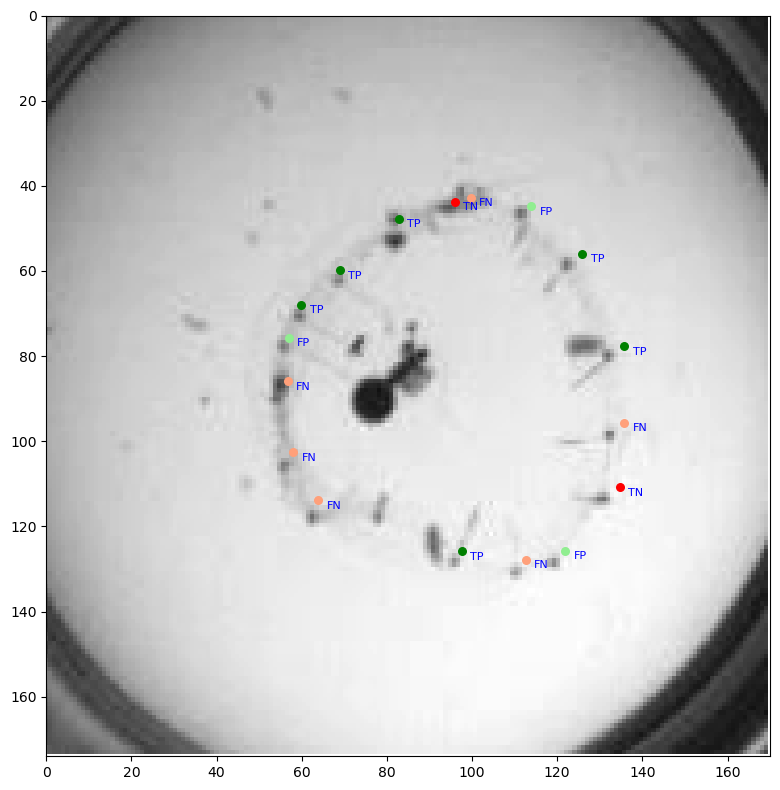

In [17]:
svm_clf_animation_path = '/home/mingxiao/Desktop/animation/svm_clf_animation_v5.mp4'
animate_classification_results(pred_pts_with_scores[1:], checked_labels, 
                               bg_video=vid, bg_video_start_idx=0, 
                               output_path=svm_clf_animation_path);


# Save prediction results

In [20]:
predicted_pts = pred_pts_with_scores[1:, :, :2]
predicted_pts[unraveled_pred_labels < 1] = 0
predicted_missing_mask = get_missing_count(predicted_pts)
print(f'missing count: {predicted_missing_mask.sum()}')

missing count: 9107.0


In [21]:
pred_result_folder = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/correction/results'
pred_result_path = os.path.join(pred_result_folder, 'pred_results_v1.npy')
np.save(pred_result_path, predicted_pts)